In [2]:
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)

In [3]:
!pip install -Uqq fastai

from fastai.vision.all import *


In [2]:
!pip install -Uqq ddgs fastcore

# 2. Import thư viện và dạy cho Python biết hàm search_images là gì
from ddgs import DDGS
from fastcore.all import *

def search_images(term, max_images=1):
    print(f"Đang tìm kiếm hình ảnh cho từ khóa: '{term}'")
    return L(DDGS().images(term, max_results=max_images)).itemgot('image')

Please find one URL pointing to an image of a damaged car.

In [35]:
urls = search_images('damaged car', 1)
urls[0]

Đang tìm kiếm hình ảnh cho từ khóa: 'damaged car'


'https://thumbs.dreamstime.com/b/crashed-car-accident-broken-vehicle-fatal-disaster-road-collision-damage-gray-get-damaged-automobile-209424454.jpg'

Đang tìm kiếm hình ảnh cho từ khóa: 'car'


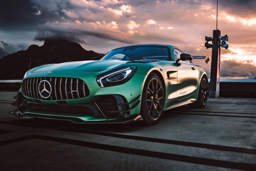

In [38]:
from fastdownload import download_url
dest = 'damaged_car.jpg'
download_url(urls[0], dest, show_progress=False)

dest = 'car.jpg'
download_url(search_images('car', 1)[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Downlaod images of damgaged car and normal car and save them in different folder

In [12]:
searches = 'damaged car','car'
path = Path('damaged_car_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo', 30))
    time.sleep(5)
    resize_images(path/o, max_size=250, dest=path/o)

Đang tìm kiếm hình ảnh cho từ khóa: 'damaged car photo'
Đang tìm kiếm hình ảnh cho từ khóa: 'car photo'


Get rid of all photos being incorrectly downloaded (if existed)

In [13]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

Create DataLoaders where we define input/output, how to load images and labels, a splitter for 20% validation and 80% training images, and how to resize the images

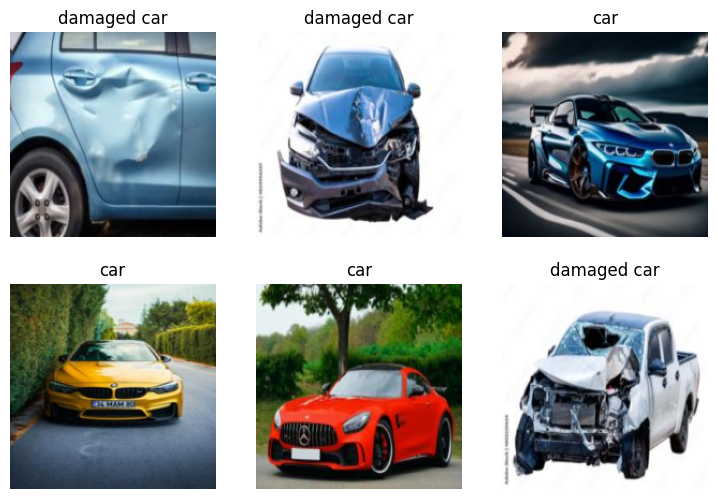

In [24]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

Train the model for 3 epoches using the resnet18-architecture

In [25]:
learner = vision_learner(dls, resnet18, metrics=error_rate)
learner.fine_tune(6)

epoch,train_loss,valid_loss,error_rate,time
0,0.827255,4.401813,0.666667,00:01


epoch,train_loss,valid_loss,error_rate,time
0,1.161821,3.674565,0.666667,00:01
1,1.014324,2.491758,0.666667,00:00
2,0.766476,1.374354,0.583333,00:00
3,0.632194,0.763910,0.416667,00:00
4,0.518087,0.464862,0.166667,00:00
5,0.429677,0.347463,0.166667,00:00


Check accuracy of model by image in the first code

In [40]:
is_damaged_car,_,probs = learner.predict(PILImage.create('damaged_car.jpg'))
print(f"This is a: {is_damaged_car}.")
print(f"Probability it's a damaged car: {probs[0]:.4f}")

is_car,_,probs = learner.predict(PILImage.create('car.jpg'))
print(f"This is a: {is_car}.")
print(f"Prob it's a car {probs[1]:.4f}")

This is a: damaged car.
Probability it's a damaged car: 0.1294


This is a: car.
Prob it's a car 0.0010
